# Lane Detection – Lab 4

In this assignment, you will build a full lane detection pipeline step-by-step.

## Pipeline Overview

1. Camera Calibration
2. Image Undistortion
3. Binary Thresholding
4. Perspective Transform
5. Lane Detection (Sliding Windows)
6. Polynomial Fitting
7. Lane Overlay

Each section contains:

- Function skeletons (you must implement)
- Visual checkpoints (required for grading)
- Clear inputs and outputs


In [1]:
# ==============================================================
# importing required libraries
# ==============================================================

import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12,6)


In [2]:
# ==============================================================
# defining dataset paths
# ==============================================================

CALIB_PATH = "camera_cal/*.jpg"
TEST_IMAGE_PATH = "test_images/straight_lines2.jpg"


In [3]:
# ==============================================================
# helper function for rgb plotting
# ==============================================================

def show_rgb(img, title="Image"):
    #converting bgr to rgb for plotting
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #displaying image
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


# Step 1 – Camera Calibration

## Why Do We Need Camera Calibration?

Real cameras introduce distortion due to lens curvature. This causes:

- Straight lines to appear slightly curved
- Objects near edges to stretch or warp

For lane detection, this distortion affects:

- Polynomial fitting
- Curvature computation
- Vehicle offset estimation

So we must remove distortion before doing any geometry.

---

## How Calibration Works

We use multiple images of a chessboard pattern.

Why a chessboard?

- It has known geometry
- All corners lie on a flat plane
- Corner spacing is uniform and predictable

---

## What OpenCV Does Internally

We use:

cv2.findChessboardCorners()

This function:
- Detects internal chessboard corner intersections
- Returns their pixel coordinates
- Uses image gradients and pattern matching internally

Then we use:

cv2.calibrateCamera()

This function:
- Solves a large optimization problem
- Estimates:
  - Camera matrix (intrinsic parameters)
  - Distortion coefficients
- Minimizes reprojection error

The camera matrix contains:
- Focal lengths (fx, fy)
- Optical center (cx, cy)

The distortion vector models:
- Radial distortion
- Tangential distortion

---

## Expected Output

- A 3x3 camera matrix
- A distortion coefficient vector
- No visible output yet, but required for undistortion


In [4]:
def collect_calibration_points(calib_images, nx=9, ny=6):
    objp = np.zeros((nx*ny, 3), np.float32)
    objp[:, :2] = np.mgrid[0:nx, 0:ny].T.reshape(-1, 2)

    objpoints = []
    imgpoints = []

    for fname in calib_images:
        img = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        ret, corners = cv2.findChessboardCorners(gray, (nx, ny), None)

        if ret:
            objpoints.append(objp)
            imgpoints.append(corners)
            img = cv2.drawChessboardCorners(img, (nx, ny), corners, ret)
            cv2.imshow('Chessboard', img)
            cv2.waitKey(500)

    cv2.destroyAllWindows()

    return objpoints, imgpoints, gray.shape[::-1]

In [5]:
def calibrate_camera(objpoints, imgpoints, img_shape):
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, img_shape, None, None)
    return mtx, dist

In [6]:
calib_images = glob.glob(CALIB_PATH)
objpoints, imgpoints, img_shape = collect_calibration_points(calib_images)
mtx, dist = calibrate_camera(objpoints, imgpoints, img_shape)
print("Calibration complete.")


Calibration complete.


# Step 2 – Image Undistortion

## What Is Undistortion?

Now that we know how the camera distorts the image,
we correct that distortion.

We use:

cv2.undistort()

This function:
- Applies inverse distortion model
- Uses camera matrix + distortion coefficients
- Produces a geometrically corrected image

---

## Why This Matters

All later steps assume:

- Straight lines are actually straight
- Pixel-to-meter conversion is valid
- Polynomial fitting represents real-world geometry

If you skip this step:
- Curvature will be incorrect
- Offset will be incorrect

---

## Expected Visual Result

You should see:

- Slight straightening near image edges
- Subtle correction
- Not dramatic, but noticeable


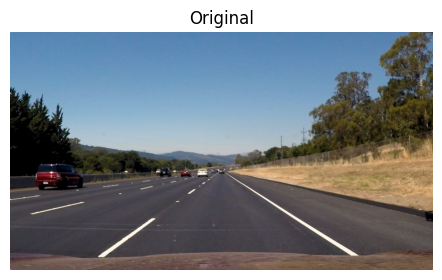

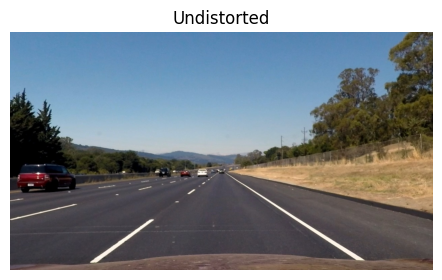

In [7]:
def undistort(img, mtx, dist):
    undist = cv2.undistort(img, mtx, dist, None, mtx)
    return undist

test_img = cv2.imread(TEST_IMAGE_PATH)

undist_img = undistort(test_img, mtx, dist)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
show_rgb(test_img, "Original")

plt.subplot(1,2,2)
show_rgb(undist_img, "Undistorted")

# Step 3 – Binary Thresholding

## Goal

Convert a complex RGB image into a clean binary mask
where:

- Lane pixels = 1
- Everything else = 0

---

## Why Binary?

Lane detection works best when:

- Noise is reduced
- Edges are clear
- Lighting variation is minimized

Binary simplifies the problem dramatically.

---

## Part A – Color Space Conversion (HLS)

We convert to HLS using:

cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

Why HLS?

- H = Hue
- L = Lightness
- S = Saturation

Lane lines:
- Have strong saturation (S channel)
- Often contrast strongly in L channel

Separating channels helps isolate lanes better than RGB.

---

## Part B – Sobel Gradient

We use:

cv2.Sobel(channel, ddepth, dx=1, dy=0)

This computes the derivative in the x-direction.

Why x-direction?

- Lane lines are mostly vertical
- Vertical lines create strong horizontal gradients

Sobel highlights edges where pixel intensity changes sharply.

We then:
- Take absolute value
- Scale to 0–255
- Apply threshold

---

## Part C – Channel Threshold

We threshold S channel:

binary[(channel >= low) & (channel <= high)] = 1

This isolates:

- Bright yellow lanes
- Bright white lanes

---

## Final Step – Combine Masks

We use logical OR:

(mask1 == 1) OR (mask2 == 1)

This keeps pixels detected by either gradient or color.

---

## Expected Output

- Clear lane lines
- Minimal background noise
- White pixel percentage typically 0%–10%


In [8]:
def convert_to_hls(img):
    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
    l_channel = hls[:, :, 1]
    s_channel = hls[:, :, 2]
    return l_channel, s_channel

def sobel_x_binary(channel, thresh=(20, 100)):
    sobelx = cv2.Sobel(channel, cv2.CV_64F, 1, 0, ksize=3)
    abs_sobel = np.absolute(sobelx)
    scaled = np.uint8(255 * abs_sobel / np.max(abs_sobel))
    binary = np.zeros_like(scaled)
    binary[(scaled >= thresh[0]) & (scaled <= thresh[1])] = 1
    return binary

def channel_threshold(channel, thresh=(120, 255)):
    binary = np.zeros_like(channel)
    binary[(channel >= thresh[0]) & (channel <= thresh[1])] = 1
    return binary

def combine_masks(mask1, mask2):
    combined = np.zeros_like(mask1)
    combined[(mask1 == 1) | (mask2 == 1)] = 1
    return combined

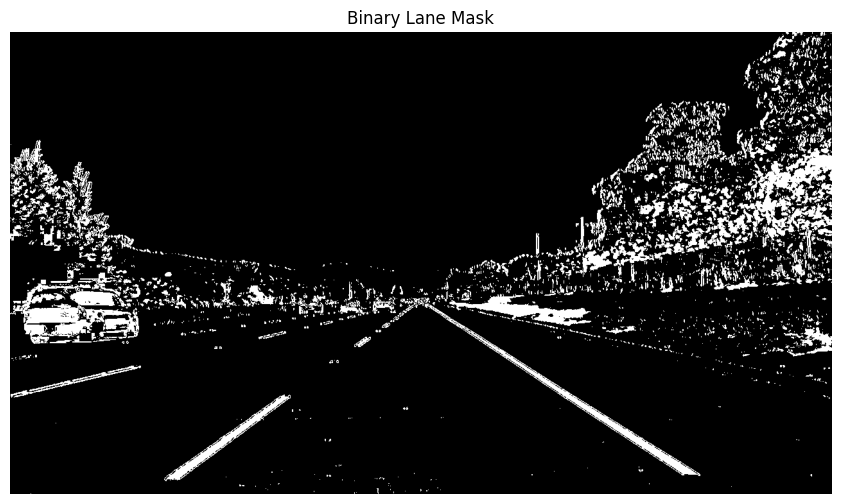

White pixel percentage: 0.08314670138888888


In [9]:
def threshold_binary(img, mtx, dist):
    undist = undistort(img, mtx, dist)
    l_channel, s_channel = convert_to_hls(undist)
    sobel_binary = sobel_x_binary(l_channel)
    s_binary = channel_threshold(s_channel)
    combined = combine_masks(sobel_binary, s_binary)
    return combined

binary_output = threshold_binary(test_img, mtx, dist)

plt.imshow(binary_output, cmap='gray')
plt.title("Binary Lane Mask")
plt.axis("off")
plt.show()

print("White pixel percentage:", np.sum(binary_output) / binary_output.size)

# Step 4 – Perspective Transform (Bird's-Eye View)

## Why Do We Warp?

In the original image:

- Lane lines converge
- Perspective distortion makes geometry nonlinear

In bird’s-eye view:

- Lane lines become nearly parallel
- Polynomial fitting becomes more stable
- Lane width becomes consistent

---

## What OpenCV Does

We compute transformation matrix:

cv2.getPerspectiveTransform(src, dst)

This calculates a 3x3 homography matrix.

Then:

cv2.warpPerspective(image, M, size)

This:
- Maps trapezoid region into rectangle
- Applies projective transformation

---

## What Is Happening Mathematically?

The transform:
- Preserves straight lines
- Maps 4 source points → 4 destination points
- Performs projective geometry

---

## Expected Visual Result

- Lanes become vertical
- Parallel appearance
- Horizon disappears


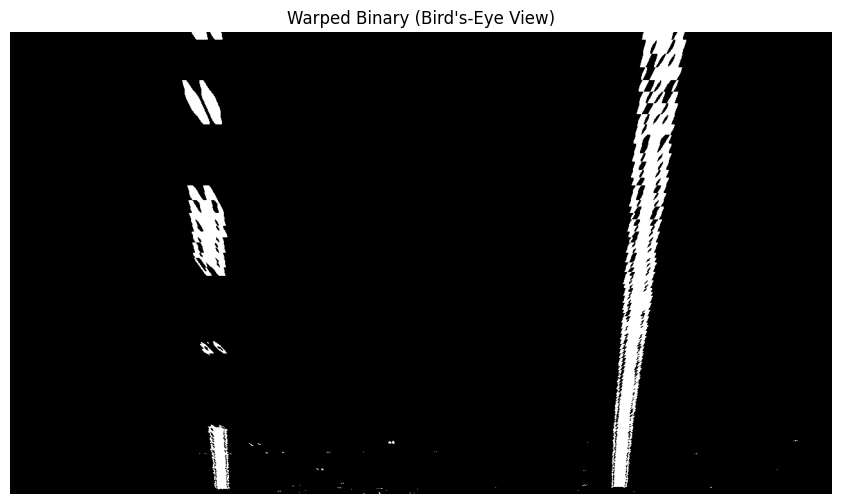

In [10]:
def get_perspective_matrices(src, dst):
    M = cv2.getPerspectiveTransform(src, dst)
    Minv = cv2.getPerspectiveTransform(dst, src)
    return M, Minv

def warp_binary(binary_img, M):
    h, w = binary_img.shape[:2]
    warped = cv2.warpPerspective(binary_img, M, (w, h))
    return warped

SRC = np.float32([
    [585, 460],
    [203, 720],
    [1127, 720],
    [695, 460]
])

DST = np.float32([
    [320, 0],
    [320, 720],
    [960, 720],
    [960, 0]
])

M, Minv = get_perspective_matrices(SRC, DST)
warped_binary = warp_binary(binary_output, M)
plt.imshow(warped_binary, cmap="gray")
plt.title("Warped Binary (Bird's-Eye View)")
plt.axis("off")
plt.show()

## Bonus (Optional) – Automatic Vanishing Point Based Warp

If you choose to attempt the bonus:
- Detect lane-ish lines using Canny + Hough
- Estimate vanishing point
- Build a trapezoid around it for `src`

This is NOT required for full marks.


In [11]:
def detect_lines_for_vp(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=40, maxLineGap=5)
    filtered_lines = []
    for line in lines:
        for x1, y1, x2, y2 in line:
            if abs(x2 - x1) < 10:  # Vertical lines
                filtered_lines.append((x1, y1, x2, y2))

    return filtered_lines

# Step 5 – Sliding Window Lane Detection

## Why Sliding Windows?

Now that lanes are vertical:

We can detect them using histogram peaks and search windows.

---

## Step 1 – Histogram

We sum bottom half of image:

np.sum(binary_warped[h//2:, :], axis=0)

This gives:

- Strong peaks where lane lines exist
- Left peak and right peak

---

## Step 2 – Window Search

We divide image vertically into N windows.

For each window:

- Define rectangle boundaries
- Find white pixels inside window
- Recenter next window using mean x position

---

## Why It Works

- Lane lines are continuous
- Pixels cluster along curve
- Histogram gives strong initialization

---

## Visualization

- Green rectangles
- Red/blue detected pixels


In [12]:
def compute_histogram(binary_warped):
    histogram = np.sum(binary_warped[binary_warped.shape[0] // 2:, :], axis=0)
    return histogram

def find_lane_bases(histogram):
    midpoint = int(histogram.shape[0] // 2)
    leftx_base = np.argmax(histogram[:midpoint])
    rightx_base = np.argmax(histogram[midpoint:]) + midpoint
    return leftx_base, rightx_base


In [13]:
def sliding_window_search(binary_warped, nwindows=9, margin=100, minpix=50):
    out_img = np.dstack((binary_warped, binary_warped, binary_warped)) * 255
    histogram = compute_histogram(binary_warped)
    leftx_base, rightx_base = find_lane_bases(histogram)

    window_height = int(binary_warped.shape[0] // nwindows)
    nonzero = binary_warped.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])

    leftx_current = leftx_base
    rightx_current = rightx_base

    left_lane_inds = []
    right_lane_inds = []

    for window in range(nwindows):
        win_y_low = binary_warped.shape[0] - (window + 1) * window_height
        win_y_high = binary_warped.shape[0] - window * window_height

        win_xleft_low = leftx_current - margin
        win_xleft_high = leftx_current + margin
        win_xright_low = rightx_current - margin
        win_xright_high = rightx_current + margin
        cv2.rectangle(out_img, (win_xleft_low, win_y_low), (win_xleft_high, win_y_high), (0, 255, 0), 2)
        cv2.rectangle(out_img, (win_xright_low, win_y_low), (win_xright_high, win_y_high), (0, 0, 255), 2)
        good_left_inds = ((nonzerox >= win_xleft_low) & (nonzerox <= win_xleft_high) & 
                          (nonzeroy >= win_y_low) & (nonzeroy <= win_y_high)).nonzero()[0]
        good_right_inds = ((nonzerox >= win_xright_low) & (nonzerox <= win_xright_high) & 
                           (nonzeroy >= win_y_low) & (nonzeroy <= win_y_high)).nonzero()[0]

        left_lane_inds.append(good_left_inds)
        right_lane_inds.append(good_right_inds)

        if len(good_left_inds) > minpix:
            leftx_current = int(np.mean(nonzerox[good_left_inds]))
        if len(good_right_inds) > minpix:
            rightx_current = int(np.mean(nonzerox[good_right_inds]))

    left_lane_inds = np.concatenate(left_lane_inds)
    right_lane_inds = np.concatenate(right_lane_inds)

    leftx = nonzerox[left_lane_inds]
    lefty = nonzeroy[left_lane_inds]
    rightx = nonzerox[right_lane_inds]
    righty = nonzeroy[right_lane_inds]

    return leftx, lefty, rightx, righty, out_img

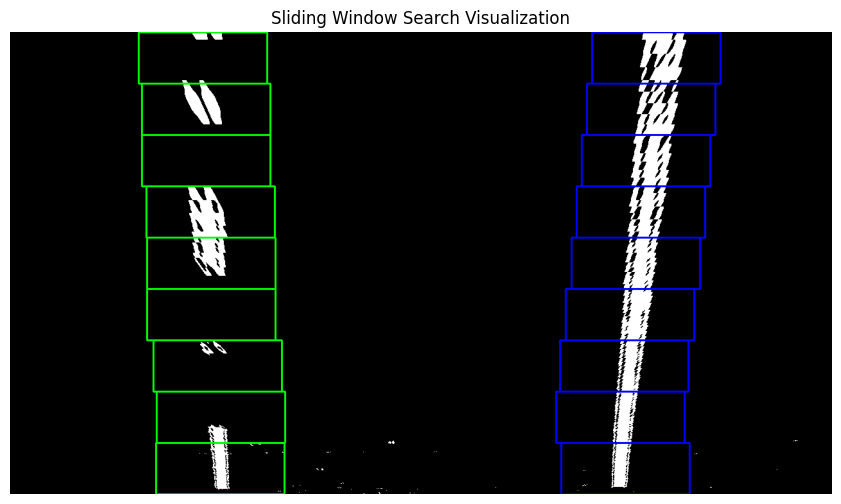

In [14]:
leftx, lefty, rightx, righty, sw_vis = sliding_window_search(warped_binary)

plt.imshow(sw_vis)
plt.title("Sliding Window Search Visualization")
plt.axis("off")
plt.show()


# Step 6 – Polynomial Fitting

## Why Polynomial?

Lanes are not straight.

We model them as:

x = Ay² + By + C

Second-order polynomial is sufficient for most roads.

---

## What np.polyfit Does

np.polyfit(y_values, x_values, 2)

It:
- Solves least squares
- Finds best-fitting quadratic curve

---

## Why Fit x as Function of y?

Because:

- y increases vertically
- Lane curves left/right as y changes

---

## Expected Result

- Smooth curve
- Aligned with detected pixels
- No sudden jumps


In [15]:
def fit_polynomial(leftx, lefty, rightx, righty, img_shape):
    ploty = np.linspace(0, img_shape[0] - 1, img_shape[0])
    left_fit = np.polyfit(lefty, leftx, 2)
    right_fit = np.polyfit(righty, rightx, 2)
    left_fitx = left_fit[0] * ploty**2 + left_fit[1] * ploty + left_fit[2]
    right_fitx = right_fit[0] * ploty**2 + right_fit[1] * ploty + right_fit[2]

    return left_fit, right_fit, ploty, left_fitx, right_fitx

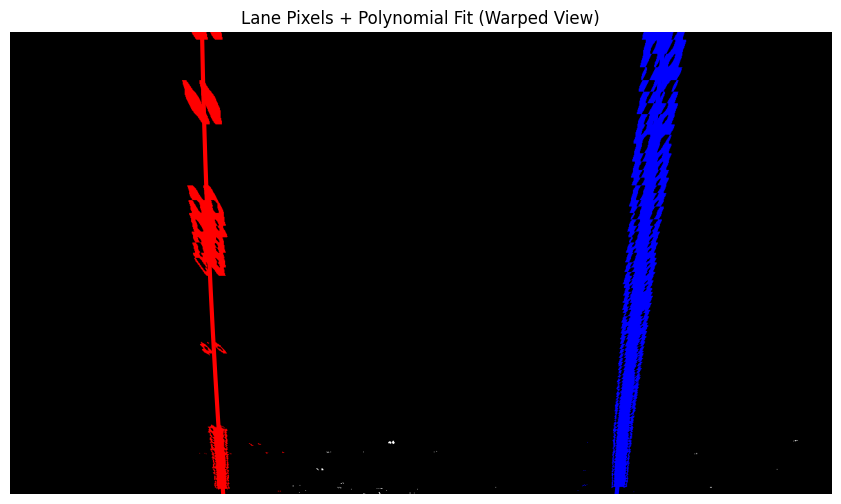

In [16]:
# Example usage
left_fit, right_fit, ploty, left_fitx, right_fitx = fit_polynomial(
    leftx, lefty, rightx, righty, warped_binary.shape
)

# Create visualization
fit_vis = np.dstack((warped_binary, warped_binary, warped_binary)) * 255

# Color lane pixels
fit_vis[lefty, leftx] = [255, 0, 0]  # Red for left lane
fit_vis[righty, rightx] = [0, 0, 255]  # Blue for right lane

# Plot fitted polynomials
plt.imshow(fit_vis)
plt.plot(left_fitx, ploty, linewidth=3, color='red')
plt.plot(right_fitx, ploty, linewidth=3, color='blue')
plt.title("Lane Pixels + Polynomial Fit (Warped View)")
plt.axis("off")
plt.show()

# Step 7 – Curvature and Vehicle Offset

## Goal

Compute:

- Radius of curvature for left and right lanes (in meters)
- Vehicle offset from lane center (in meters)

---

## Radius of Curvature Formula

For a second-order polynomial:

x = Ay² + By + C

The radius of curvature at position y is:

R = ((1 + (2Ay + B)²)^(3/2)) / |2A|

Where:

- A and B are coefficients from the polynomial fit
- y is the evaluation point (bottom of the image)
- The polynomial must be fitted in real-world units (meters)

---

## Important Notes

Before computing curvature:

1. Convert pixels → meters
2. Re-fit polynomial in real-world space
3. Evaluate curvature at the bottom of the image

We use typical lane conversion factors:

- 30 meters per 720 pixels (vertical)
- 3.7 meters per 700 pixels (horizontal)

---

## Vehicle Offset

Vehicle offset is computed as:

offset = (image_center − lane_center) × meters_per_pixel

Where:

- lane_center = midpoint between left and right lanes at bottom
- image_center = center of image width


In [17]:
def measure_curvature_real(left_fitx, right_fitx, ploty, ym_per_pix=30/720, xm_per_pix=3.7/700):
    y_eval = np.max(ploty)
    

    left_fit_cr = np.polyfit(ploty * ym_per_pix, left_fitx * xm_per_pix, 2)
    right_fit_cr = np.polyfit(ploty * ym_per_pix, right_fitx * xm_per_pix, 2)
    

    left_curverad = ((1 + (2 * left_fit_cr[0] * y_eval + left_fit_cr[1])**2)**1.5) / np.abs(2 * left_fit_cr[0])
    right_curverad = ((1 + (2 * right_fit_cr[0] * y_eval + right_fit_cr[1])**2)**1.5) / np.abs(2 * right_fit_cr[0])
    
    return left_curverad, right_curverad

def measure_vehicle_offset(img_shape, left_fitx, right_fitx, xm_per_pix=3.7/700):

    lane_center = (left_fitx[-1] + right_fitx[-1]) / 2
    
    
    image_center = img_shape[1] / 2
    

    offset_pixels = image_center - lane_center
    

    offset_m = offset_pixels * xm_per_pix
    
    return offset_m


In [18]:
# computing curvature
left_curverad, right_curverad = measure_curvature_real(
    left_fitx,
    right_fitx,
    ploty
)

# computing vehicle offset
offset_m = measure_vehicle_offset(
    test_img.shape,
    left_fitx,
    right_fitx
)

print("Left curvature (m):", left_curverad)
print("Right curvature (m):", right_curverad)
print("Vehicle offset (m):", offset_m)


Left curvature (m): 4445.615936343955
Right curvature (m): 999235.3590475839
Vehicle offset (m): 0.008735934996816777


# Step 8 – Overlay Lane Back Onto Original Image

## What We Do

1. Create blank image
2. Draw filled polygon between left and right curves
3. Warp it back using inverse perspective matrix
4. Blend with original image

---

## Why Warp Back?

Lane detection was done in bird’s-eye view.

To visualize properly:
- Transform lane area back to camera view

---

## What cv2.addWeighted Does

result = alpha * original + beta * overlay

This creates transparent green lane region.

---

## Final Output Should Show

- Undistorted road
- Green lane region
- Curvature text
- Offset text



In [19]:
def draw_lane_overlay(original_img, warped_binary, left_fitx, right_fitx, ploty, Minv):

    warp_zero = np.zeros_like(warped_binary).astype(np.uint8)
    color_warp = np.dstack((warp_zero, warp_zero, warp_zero))  

    pts_left = np.array([np.transpose(np.vstack([left_fitx, ploty]))])
    pts_right = np.array([np.flipud(np.transpose(np.vstack([right_fitx, ploty])))])
    pts = np.hstack((pts_left, pts_right))


    cv2.fillPoly(color_warp, np.int32([pts]), (0, 255, 0))

 
    newwarp = cv2.warpPerspective(color_warp, Minv, (original_img.shape[1], original_img.shape[0]))

   
    result = cv2.addWeighted(original_img, 1, newwarp, 0.3, 0)

    return result


def annotate_result(img, left_curverad, right_curverad, offset_m):

    curvature_text = f"Left Curvature: {left_curverad:.2f}m, Right Curvature: {right_curverad:.2f}m"
    

    offset_text = f"Vehicle Offset: {offset_m:.2f}m"


    cv2.putText(img, curvature_text, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(img, offset_text, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    return img


# Step 9 – Full Pipeline Function

Goal:
Build `process_image(img)` that runs the full pipeline:

1. Undistort
2. Threshold to binary
3. Warp to bird’s-eye view
4. Sliding windows search
5. Polynomial fit
6. Curvature + offset
7. Overlay + annotation


In [20]:
def process_image(img, mtx, dist, M, Minv):
    undist = undistort(img, mtx, dist)
    binary = threshold_binary(img, mtx, dist)
    warped = warp_binary(binary, M)
    leftx, lefty, rightx, righty, _ = sliding_window_search(warped)

    left_fit, right_fit, ploty, left_fitx, right_fitx = fit_polynomial(
        leftx, lefty, rightx, righty, warped.shape
    )

    left_curverad, right_curverad = measure_curvature_real(left_fitx, right_fitx, ploty)

    offset_m = measure_vehicle_offset(img.shape, left_fitx, right_fitx)

    result = draw_lane_overlay(undist, warped, left_fitx, right_fitx, ploty, Minv)

    result = annotate_result(result, left_curverad, right_curverad, offset_m)

    return result



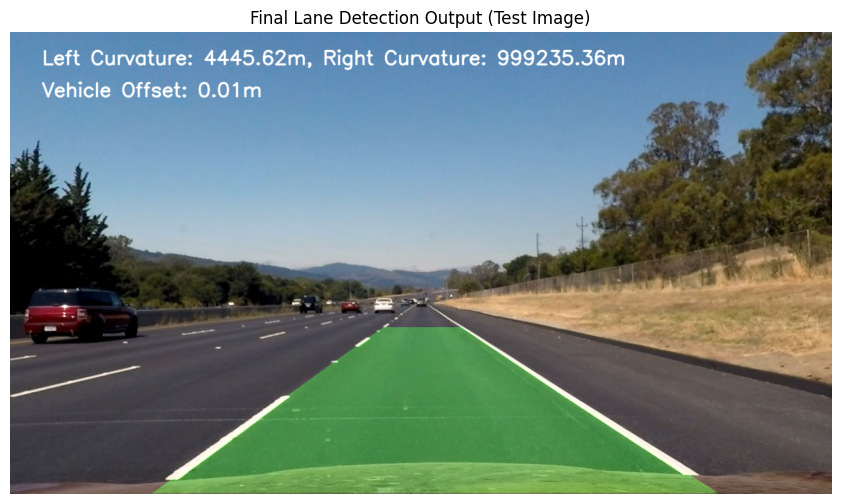

In [21]:
final_output = process_image(test_img, mtx, dist, M, Minv)
show_rgb(final_output, "Final Lane Detection Output (Test Image)")


# Step 10 – Video Processing (Optional)

If you complete this section:
- Run your pipeline on every frame
- Save an output video

This section is optional.


In [22]:
def process_video_opencv(input_path, output_path, mtx, dist, M, Minv):
    cap = cv2.VideoCapture(input_path)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # Codec for output video
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        result = process_image(frame, mtx, dist, M, Minv)

        out.write(result)

    cap.release()
    out.release()

    print("Video processing complete.")

# Submission Checklist (Required Visual Deliverables)

Your notebook must include these outputs:

## Checkpoint 1 – Undistortion
- Original image
- Undistorted image

## Checkpoint 2 – Binary Threshold
- Binary lane mask image
- Printed white pixel percentage

## Checkpoint 3 – Perspective Warp
- Warped binary image

## Checkpoint 4 – Sliding Window Visualization
- Window visualization image

## Checkpoint 5 – Polynomial Fit Visualization
- Warped view with lane pixels + fitted curves

## Checkpoint 6 – Final Output
- Final lane overlay on original image
- Curvature + offset shown (numbers can be approximate)

Optional:
- Output video saved
